# <span style="color: #1F1DB5;">SPRINT 9 - Introducción al machine learning

# <span style="color: #1F1DB5;">Notebook 1 – Modelos de Aprendizaje automático

## <span style="color: #2826DE;">Objetivos de Aprendizaje

- Introducir los conceptos fundamentales para comprender qué es el **Machine Learning (ML)** y cómo se utiliza en Data Science.
- Diferenciar los principales tipos de aprendizaje automático: **clasificación**, **regresión** y **clustering**.
- Comprender de forma visual cómo los modelos generan **fronteras de decisión** para resolver problemas de clasificación.
- Comparar la toma de decisiones **manual vs automática**, entendiendo cómo los algoritmos aprenden a partir de datos.
- Conocer qué es el **sobreajuste** y cómo **evitarlo** al entrenar modelos de ML.
- Ejecutar un primer ejemplo práctico de ML para observar cómo un modelo puede **aprender patrones a partir de datos reales**.

### <span style="color: #2772F2;">Agenda (2 horas)

| Tema | Duración |
|---|---|
Ejemplo visual: cómo aprende un modelo | 20 min |
Introducción al Machine Learning | 15 min |
Tipos de aprendizaje automático (clasificación, regresión, clustering) | 20 min |
Fronteras de decisión y clasificación | 20 min |
Evitar el sobreajuste en modelos de ML | 20 min |
Ejercicio práctico guiado | 15 min |
Tips y buenas prácticas | 5 min |
Cierre y Kahoot | 5 min |


# <span style="color: #2826DE;">Requerimientos

Para esta sesión necesitaremos:

- Python 3.9+
- Jupyter Notebook / Google Colab
- Librerías:
  - numpy
  - pandas
  - matplotlib
  - seaborn
  - scikit-learn

Si estás en Colab puedes instalar con:

```python
!pip install numpy pandas matplotlib seaborn scikit-learn

## <span style="color: #2826DE;">❓ Pregunta Guía

### ¿Cómo es posible que mi Netflix me recomiende películas, que Spotify me sugiera música y que muchas de esas sugerencias sí me gusten… sin que yo les diga exactamente mis preferencias?



<img src="../Images/S9_DS_netflix.jpg" length="600">

En esta sesión veremos cómo funciona el **Machine Learning**, una de las áreas más importantes de **Data Science**, y cómo los **algoritmos** pueden realmente **APRENDER** patrones a partir de los datos.

Hoy entrenaremos nuestros primeros modelos y veremos cómo una máquina puede aprender a **clasificar información**.

# <span style="color: #2826DE;">Ejemplo visual: cómo aprende un modelo (20 min)

Antes de estudiar teoría, vamos a ver un ejemplo rápido de lo que puede hacer el Machine Learning.

Vamos a crear datos artificiales y entrenar un modelo para que aprenda a separarlos automáticamente.

La idea es responder esta pregunta:

> ¿Puede una computadora aprender a clasificar datos sin que le digamos exactamente las reglas?

### <span style="color:#2772F2;">Paso 1 — Clasificación manual de clases

### ¿Cómo separarías los datos?

Imaginemos que estos datos son referentes a una tarea de clasificación, la información pertenece a personas que usan una plataforma de streaming de películas y los datos describen las características de aquellos que prefieren el género de:
- <span style="color: #2826DE;"> TERROR
- <span style="color: #e71c15;"> COMEDIA

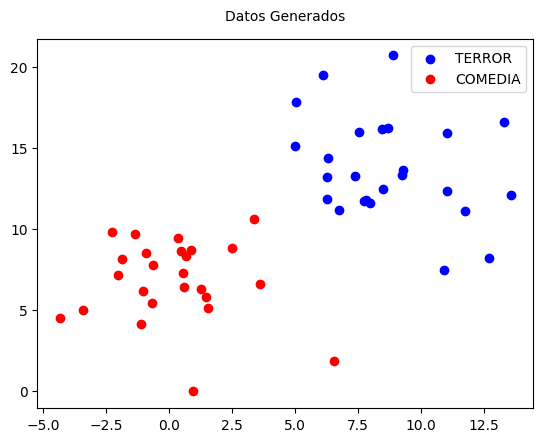

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=1,
    cluster_std=3,
    center_box= (0.0,20.0)
)
fig, ax = plt.subplots()
# Puntos
ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="TERROR")
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="COMEDIA")

title = ax.text(0.5, 1.05, "Datos Generados", transform=ax.transAxes, ha="center")

ax.legend()
plt.show()





A primera vista parece fácil separarlos, ya que el terror y la comedia suelen ser géneros bien diferenciados que no guardan mucha relación entre sí.

Pero ahora, imagina estos nuevos datos, corresponden a los géneros:
- <span style="color: #2826DE;"> TERROR PSICOLÓGICO
- <span style="color: #e71c15;"> TERROR SOBRENATURAL

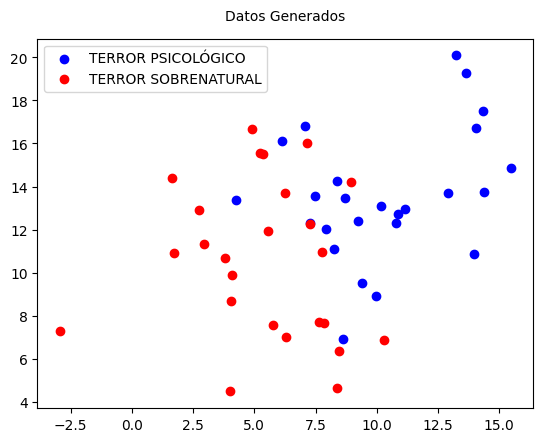

In [12]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=3,
    cluster_std=3,
    center_box= (0.0,20.0)
)
fig, ax = plt.subplots()
# Puntos
ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="TERROR PSICOLÓGICO")
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="TERROR SOBRENATURAL")

title = ax.text(0.5, 1.05, "Datos Generados", transform=ax.transAxes, ha="center")

ax.legend()
plt.show()

### Preguntas:

- **¿Sigue siendo igual de facil separar datos que se relacionan más entre ellos?**
- **¿Donde colocarías la frontera de decision?**

### <span style="color:#2772F2;">Paso 2 — Clasificación automática de clases

Ya que hicimos este ejercicio de manera manual, observemos cómo sería entrenar un modelo para que aprenda a separarlos.

(Archivo _DS_Sprint9_Perceptron_visual_training_ )

### Preguntas:

- **¿Consideras que el modelo fue capaz de colocar la frontera de decisión de manera adecuada en cada caso?**
- **¿Qué podríamos hacer para asegurarnos de que el modelo pueda encontrar siempre la mejor frontera de decisión?**

<img src="../Images/S9_DS_good_choice.jpg" length="200">

## <span style="color: #2826DE;">Introducción al Machine Learning (15 mins)

### <span style="color: #2772F2;">¿Qué es Machine Learning?

El **Machine Learning (Aprendizaje Automático)** es una rama de la Inteligencia Artificial que permite a las computadoras **aprender patrones a partir de datos** sin que tengamos que programar cada regla manualmente.

En lugar de escribir instrucciones paso a paso, en Machine Learning:

- Le damos datos al algoritmo
- El algoritmo aprende relaciones
- El modelo toma decisiones automáticamente



### <span style="color: #2772F2;">Programación tradicional vs Machine Learning

<img src="../Images/S9_DS_rule_based_vs_ml.png" width="800">


En Machine Learning, el modelo aprende las reglas a partir de los datos.


### <span style="color: #2772F2;">¿Qué hace un modelo de Machine Learning?

Un modelo aprende a partir de ejemplos.

Ejemplo:

| Edad | Ingreso | Compra |
|------|--------|--------|
| 25   | 8000   | Sí |
| 40   | 20000  | Sí |
| 18   | 3000   | No |

El modelo aprende la relación entre variables para poder predecir nuevos casos.



### <span style="color: #2772F2;">Tipos principales de Machine Learning

Existen tres tipos principales:

1. Aprendizaje supervisado
2. Aprendizaje no supervisado
3. Aprendizaje por refuerzo

En este bootcamp trabajaremos principalmente con:

- Clasificación
- Regresión
- Clustering

En la siguiente sección veremos cada uno.

## <span style="color: #2826DE;">Tipos de aprendizaje automático (20 min)

En Machine Learning, los problemas que resolvemos generalmente se agrupan en tres grandes categorías:

1. **Clasificación**
2. **Regresión**
3. **Clustering**

Cada uno se utiliza para responder preguntas diferentes a partir de los datos.


### <span style="color: #2772F2;">Clasificación

La **clasificación** consiste en predecir **una categoría o clase**.

El modelo aprende a asignar una etiqueta a cada observación.

Ejemplos:

- Detectar si un correo es **spam o no spam**
- Clasificar una imagen como **perro o gato**
- Predecir si un cliente **comprará o no comprará**

Ejemplo de salida:

| Cliente | Probabilidad de compra | Predicción |
|--------|------------------------|------------|
| A | 0.82 | Compra |
| B | 0.30 | No compra |

Los modelos de clasificación generan **fronteras de decisión**, como vimos en el ejercicio anterior.


### <span style="color: #2772F2;">Regresión

La **regresión** se utiliza cuando queremos predecir **valores numéricos continuos**.

Ejemplos:

- Predecir el **precio de una casa**
- Estimar **ventas futuras**
- Predecir **temperatura**

Ejemplo:

| Tamaño casa | Precio |
|-------------|-------|
| 80 m² | 120,000 |
| 120 m² | 180,000 |
| 200 m² | 300,000 |

El modelo aprende la relación entre las variables para estimar nuevos valores.


### <span style="color: #2772F2;">Clustering

El **clustering** busca **encontrar grupos dentro de los datos** sin que las categorías estén definidas previamente.

Esto se llama **aprendizaje no supervisado**.

Ejemplos:

- Segmentación de clientes
- Agrupar usuarios con comportamientos similares
- Detectar patrones en datos

Ejemplo:

Un algoritmo puede agrupar clientes según:

- edad
- ingresos
- hábitos de compra

El resultado son **clusters o grupos de comportamiento similar**.

### <span style="color: #2772F2;">Comparación rápida

| Tipo de problema | Tipo de salida | Ejemplo |
|-----------------|---------------|--------|
| Clasificación | Categoría | Spam / No spam |
| Regresión | Número | Precio de una casa |
| Clustering | Grupos | Segmentación de clientes |

En este módulo comenzaremos trabajando principalmente con **problemas de clasificación**, que son muy comunes en aplicaciones de Machine Learning.

## <span style="color: #2826DE;">Fronteras de decisión y clasificación (20 min)


### <span style="color: #2772F2;">Fronteras de decisión

En problemas de **clasificación**, el modelo debe decidir a qué grupo pertenece cada dato.

Para hacerlo, el algoritmo aprende una regla que separa los datos en el espacio.

A esta separación se le llama:

#### **Frontera de decisión**

Es la línea (o curva) que divide las clases.


### <span style="color: #2772F2;">Ejemplo conceptual

Supongamos que queremos clasificar puntos en dos grupos.

Cada punto tiene dos variables:

- X1
- X2

El modelo intenta encontrar una línea que los separe.


El modelo aprende una línea que divide los grupos

La línea que separa los grupos es la **frontera de decisión**.

### <span style="color: #2772F2;">Recordando el ejemplo anterior

En el ejercicio anterior entrenamos un modelo para separar dos grupos de datos.

Vamos a visualizar nuevamente la frontera de decisión.

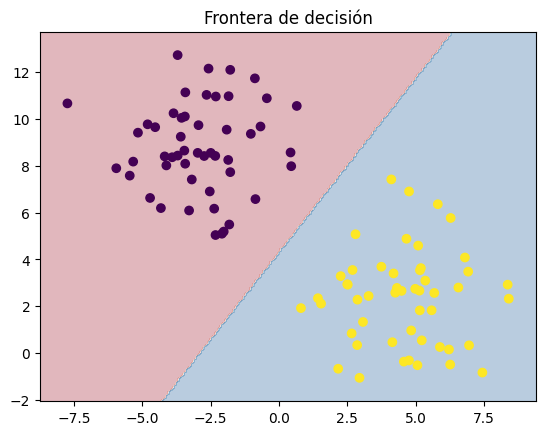

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=2
)

model = LogisticRegression()
model.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Frontera de decisión")
plt.show()

El modelo aprendió automáticamente dónde dividir los datos.

Todo lo que queda de un lado pertenece a una clase.

Todo lo que queda del otro lado pertenece a otra.



### Importante

Distintos modelos pueden generar **distintas fronteras de decisión**.

Algunos modelos generan líneas rectas.

Otros generan curvas más complejas.

Esto lo veremos en los siguientes notebooks cuando usemos:

- Logistic Regression
- Decision Trees
- Random Forest
- KNN

## <span style="color: #2826DE;">Ejercicio práctico guiado (15 min)

Ahora vamos a experimentar con el modelo.

El objetivo es ver cómo cambian los resultados cuando modificamos los datos.

En Machine Learning, pequeños cambios pueden afectar mucho el resultado.

Vamos a generar nuevos datos con más dificultad.

### <span style="color: #2772F2;">Paso 1 — Generar datos más difíciles

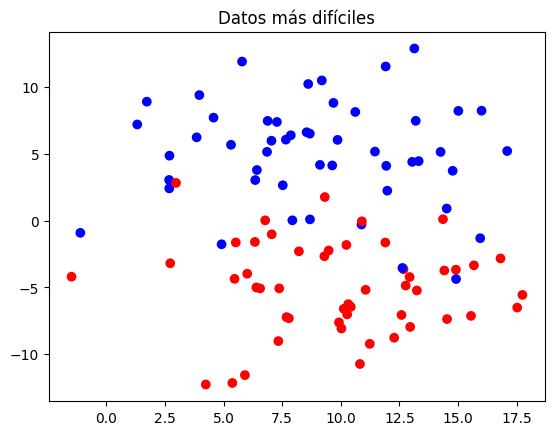

In [33]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=24,
    cluster_std=4
)

plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")
plt.title("Datos más difíciles")
plt.show()

Observa que ahora los grupos están más mezclados.

Será más difícil separarlos.

### <span style="color: #2772F2;">Paso 2 — Entrenar el modelo

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### <span style="color: #2772F2;">Paso 3 — Visualizar frontera de decisión

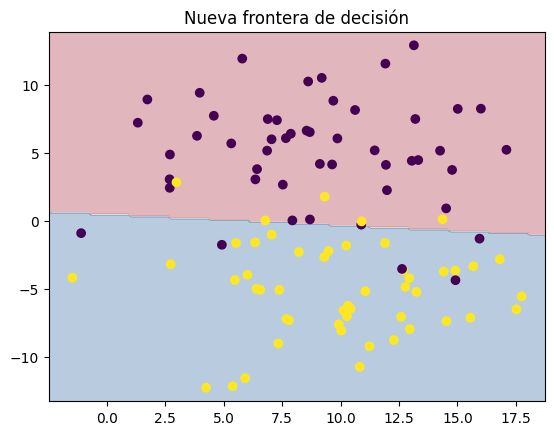

In [31]:
import numpy as np

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Nueva frontera de decisión")
plt.show()

### Preguntas

- ¿Fue más difícil separar los datos?
- ¿El modelo se equivoca más?
- ¿Qué pasaría si usamos otro algoritmo?

En Machine Learning, los resultados dependen de:

- Los datos
- El modelo
- Los parámetros
- La forma de evaluar


## <span style="color: #2826DE;">Evitar el sobreajuste en modelos de ML (20 min)

En Machine Learning no solo queremos que el modelo aprenda…

Queremos que aprenda de forma que funcione con datos nuevos.

A veces un modelo aprende demasiado bien los datos de entrenamiento.

A esto se le llama:

#### **Overfitting (sobreajuste)**



### <span style="color: #2772F2;">Analogía del examen de matemáticas

Imagina que tienes un examen de matemáticas.

El profesor te da un problemario con 100 ejercicios para estudiar.

Decides practicar así:

- 80 problemas → para estudiar (entrenamiento)
- 10 problemas → para comprobar si vas bien (validación)
- 10 problemas → serán el examen final (prueba)


Tu objetivo no es memorizar…

Tu objetivo es aprender a resolver problemas nuevos.



### <span style="color: #2772F2;">Caso 1 — Aprendizaje correcto

El alumno practica los ejercicios,
entiende el método,
y puede resolver problemas nuevos.

Resultado:

✔ Buen desempeño en el examen  
✔ Buen aprendizaje  
✔ Generalización

### <span style="color: #2772F2;">Caso 2 — Overfitting

El alumno se aprende de memoria los 80 ejercicios.

Puede resolver perfectamente los ejercicios que ya vio.

Pero cuando llega el examen…

Los problemas son diferentes.

Resultado:

✔ Excelente en entrenamiento  
❌ Malo en el examen  
❌ No aprendió realmente


Esto es exactamente lo que pasa con algunos modelos.

<img src="../Images/S9_DS_overfitting.jpg" length="700">

### <span style="color: #2772F2;">Overfitting en Machine Learning

En Machine Learning usamos datos separados:

- Train → para entrenar
- Validation → para ajustar
- Test → para evaluar

Si el modelo aprende demasiado los datos de entrenamiento,
puede fallar con datos nuevos.

Eso es overfitting.



### <span style="color: #2772F2;">Idea clave

Un buen modelo no es el que memoriza.

Un buen modelo es el que puede predecir correctamente datos que nunca ha visto.


En los siguientes notebooks veremos:

- train / test split
- validación
- métricas
- regularización
- modelos más complejos

## <span style="color: #2826DE;">Tips y buenas prácticas (5 mins)

En Machine Learning, no todo se trata de entrenar modelos.

Estas son algunas buenas prácticas que usaremos durante todo el módulo.


### ✔ No usar todos los datos para entrenar

Siempre debemos separar:

- entrenamiento
- validación
- prueba

Esto evita el overfitting.


### ✔ Visualizar los datos siempre que sea posible

Antes de entrenar un modelo:

- graficar
- explorar
- entender los datos

Un buen análisis ayuda más que un modelo complejo.


### ✔ No confiar solo en una métrica

Accuracy no siempre es suficiente.

Más adelante veremos:

- Precision
- Recall
- F1-score
- Confusion matrix


### ✔ Modelos simples primero

Siempre empieza con modelos simples:

- Logistic Regression
- Linear Regression
- Decision Trees

Después probamos modelos más complejos.


### ✔ Machine Learning no es magia

El resultado depende de:

- los datos
- el modelo
- los parámetros
- la evaluación

Un buen Data Scientist prueba, compara y analiza.

## <span style="color: #2826DE;">Cierre + Kahoot (20 mins)</span>

Hoy vimos el primer contacto con Machine Learning.

Aprendimos:

- Qué es Machine Learning
- Tipos de problemas
- Fronteras de decisión
- Evaluación de modelos
- Overfitting
- Por qué separar datos

En los siguientes notebooks empezaremos a trabajar con modelos reales paso a paso.


Ahora vamos a hacer un Kahoot rápido para reforzar conceptos.


Kahoot – Preguntas sugeridas


1️⃣ ¿Qué es Machine Learning?

- Programar reglas manualmente  
- Aprender patrones a partir de datos ✅  
- Dibujar gráficos  
- Guardar información  



2️⃣ ¿Cuál de estos es un problema de clasificación?

- Predecir el precio de una casa  
- Agrupar clientes  
- Detectar spam en correos ✅  
- Calcular promedio  



3️⃣ ¿Qué es una frontera de decisión?

- Una línea que separa clases ✅  
- Un tipo de dataset  
- Una métrica  
- Un algoritmo  



4️⃣ ¿Qué mide el accuracy?

- Cantidad de datos  
- Porcentaje de aciertos ✅  
- Tiempo de entrenamiento  
- Número de variables  



5️⃣ ¿Qué es overfitting?

- Cuando el modelo aprende demasiado los datos de entrenamiento ✅  
- Cuando el modelo no aprende nada  
- Cuando faltan datos  
- Cuando hay pocos modelos  



6️⃣ ¿Por qué se separan los datos en train y test?

- Para usar menos memoria  
- Para evitar overfitting y evaluar correctamente ✅  
- Para hacer gráficos  
- Para que el código sea más corto